# Faza 2 — EDA: Home Credit Default Risk

Notebook jest **cienkim sterownikiem** nad `src/eda.py` (spec D6). Liczby
powstają w testowanych funkcjach, a nie tutaj — dzięki temu tabele
w `docs/findings/02-eda.md` nie mogą rozjechać się z analizą.

Cel: sklasyfikować każdą kolumnę (zostaw / usuń / przetwórz), zrozumieć
**przyczynę** każdego braku i zaprojektować cechy pochodne.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from data import load_data
from eda import (
    cardinality_report,
    correlation_screen,
    missingness_report,
    target_rate_by_bin,
)

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

df = load_data()
df.shape

(307511, 122)

## 1. Cel i niezbalansowanie klas

Punkt kontrolny: te liczby muszą zgadzać się z `docs/findings/00-data-contract.md`.
Jeśli się nie zgadzają, kontrakt danych został naruszony i EDA nie ma sensu.

Wierszy: 307,511  |  kolumn: 122
Udział klasy pozytywnej: 8.0729%


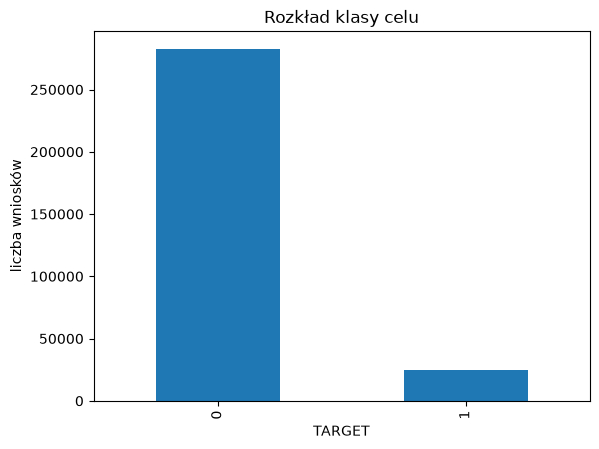

In [2]:
rate = df["TARGET"].mean()
print(f"Wierszy: {len(df):,}  |  kolumn: {df.shape[1]}")
print(f"Udział klasy pozytywnej: {rate:.4%}")

ax = df["TARGET"].value_counts().plot.bar(title="Rozkład klasy celu")
ax.set_xlabel("TARGET")
ax.set_ylabel("liczba wniosków")
plt.show()

## 2. Braki danych — i ich przyczyny

Spec D3 wymaga obsługi **per przyczyna**, nie jedną strategią. Cztery
przyczyny, jakie tu występują:

| Przyczyna | Znaczenie | Obsługa |
|---|---|---|
| `structural` | atrybut nie istnieje dla tego wiersza (blok mieszkaniowy) | decyzja blokowa |
| `not_applicable` | warunkowe od innej kolumny (`OWN_CAR_AGE`) | imputacja + **wskaźnik** |
| `unknown` | po prostu nie zebrano | mediana/moda |
| `sentinel` | zakodowane wartością magiczną, nie NaN | dekodowanie w `FeatureEngineer` |

In [3]:
miss = missingness_report(df)
print(f"Kolumn z jakimkolwiek brakiem: {(miss['n_missing'] > 0).sum()} / {df.shape[1]}")
miss[miss["n_missing"] > 0]

Kolumn z jakimkolwiek brakiem: 67 / 122


,column,dtype,n_missing,pct_missing
0,COMMONAREA_AVG,float64,214865,69.872297
1,COMMONAREA_MODE,float64,214865,69.872297
2,COMMONAREA_MEDI,float64,214865,69.872297
3,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.432963
4,NONLIVINGAPARTMENTS_MODE,float64,213514,69.432963
5,NONLIVINGAPARTMENTS_AVG,float64,213514,69.432963
6,FONDKAPREMONT_MODE,object,210295,68.386172
7,LIVINGAPARTMENTS_AVG,float64,210199,68.354953
8,LIVINGAPARTMENTS_MEDI,float64,210199,68.354953
9,LIVINGAPARTMENTS_MODE,float64,210199,68.354953


### 2a. Weryfikacja przyczyny `not_applicable`

Hipoteza: `OWN_CAR_AGE` jest puste dokładnie wtedy, gdy klient nie ma auta.
Sprawdzamy, zamiast zakładać.

In [4]:
pd.crosstab(df["FLAG_OWN_CAR"], df["OWN_CAR_AGE"].isna())

OWN_CAR_AGE,False,True
FLAG_OWN_CAR,,
N,0,202924
Y,104582,5


## 3. Wartość sentinelowa w `DAYS_EMPLOYED`

`365243` dni to ~1000 lat stażu. Tak zbiór koduje "niezatrudniony".
Zostawiona liczba wchodzi do `StandardScaler` jako wartość oddalona
o setki odchyleń standardowych.

In [5]:
print(df["DAYS_EMPLOYED"].describe().to_string())

sentinel = df["DAYS_EMPLOYED"] == 365243
print(f"\nUdział wierszy z sentinelem: {sentinel.mean():.4%}")
df.groupby(sentinel)["TARGET"].agg(["size", "mean"])

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000

Udział wierszy z sentinelem: 18.0072%


,size,mean
DAYS_EMPLOYED,,
False,252137,0.086600
True,55374,0.053996


### 3a. Niespodzianka: `FLAG_EMP_PHONE` **jest** tą flagą

Nieudokumentowane, ale dane mówią jasno: `FLAG_EMP_PHONE == 0` dla
wszystkich wierszy z sentinelem i tylko dla 12 innych. Nasza cecha
`FLAG_NOT_EMPLOYED` jest jej niemal dokładnym duplikatem.

**Decyzja:** zostawiamy jawną `FLAG_NOT_EMPLOYED` (wyprowadzoną z sentinela
z definicji, więc dokładną i samoopisującą się), a `FLAG_EMP_PHONE`
usuwamy jako duplikat o korelacji 0.9998.

In [6]:
print(pd.crosstab(df["FLAG_EMP_PHONE"], sentinel).to_string())
print("\nIdentyczne z 1 - sentinel:", bool((df["FLAG_EMP_PHONE"] == (~sentinel)).all()))

DAYS_EMPLOYED    False  True 
FLAG_EMP_PHONE               
0                   12  55374
1               252125      0

Identyczne z 1 - sentinel: False


## 4. Liczność kategorii

**Faza 4 wymiaruje z tej tabeli `nn.Embedding`.** Dlatego trafia ona do
pliku findings, a nie tylko na ekran.

In [7]:
cards = cardinality_report(df)
cards

,column,n_unique,top_value,top_share
0,ORGANIZATION_TYPE,58,Business Entity Type 3,0.221104
1,OCCUPATION_TYPE,18,Laborers,0.261396
2,NAME_INCOME_TYPE,8,Working,0.516320
3,NAME_TYPE_SUITE,7,Unaccompanied,0.811596
4,WALLSMATERIAL_MODE,7,Panel,0.436859
5,WEEKDAY_APPR_PROCESS_START,7,TUESDAY,0.175282
6,NAME_FAMILY_STATUS,6,Married,0.638780
7,NAME_HOUSING_TYPE,6,House / apartment,0.887344
8,NAME_EDUCATION_TYPE,5,Secondary / secondary special,0.710189
9,FONDKAPREMONT_MODE,4,reg oper account,0.759443


## 5. Redundancja

Blok mieszkaniowy opisuje te same ~14 pojęć trzy razy: `_AVG`, `_MEDI`,
`_MODE`. To jedna decyzja blokowa, nie 42 osobne.

In [8]:
pairs = correlation_screen(df.drop(columns=["SK_ID_CURR", "TARGET"]), threshold=0.95)
print(f"Par o |r| >= 0.95: {len(pairs)}")
pairs

Par o |r| >= 0.95: 46


,left,right,correlation
0,DAYS_EMPLOYED,FLAG_EMP_PHONE,0.999755
1,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998495
2,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998490
3,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.997241
4,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997034
5,ENTRANCES_AVG,ENTRANCES_MEDI,0.996886
6,ELEVATORS_AVG,ELEVATORS_MEDI,0.996099
7,COMMONAREA_AVG,COMMONAREA_MEDI,0.995978
8,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.995596
9,APARTMENTS_AVG,APARTMENTS_MEDI,0.995081


### 5a. Flagi dokumentów

Dwadzieścia kolumn `FLAG_DOCUMENT_*`. Reguła mechaniczna, nie wybieranie
po uważaniu: **kolumna, w której wartość dominująca pokrywa >= 99%
wierszy, nie niesie informacji** — po one-hot i standaryzacji zostaje
z niej szum.

In [9]:
docs = [c for c in df.columns if c.startswith("FLAG_DOCUMENT_")]
doc_table = pd.DataFrame(
    [
        {
            "column": c,
            "top_share": df[c].value_counts(normalize=True).iloc[0],
            "mean": df[c].mean(),
            "corr_target": df[c].corr(df["TARGET"]),
        }
        for c in docs
    ]
).sort_values("top_share", ascending=False)
print(f"Do usunięcia (top_share >= 0.99): {(doc_table['top_share'] >= 0.99).sum()}")
doc_table

Do usunięcia (top_share >= 0.99): 16


,column,top_share,mean,corr_target
10,FLAG_DOCUMENT_12,0.999993,0.000007,-0.000756
8,FLAG_DOCUMENT_10,0.999977,0.000023,-0.001414
0,FLAG_DOCUMENT_2,0.999958,0.000042,0.005417
2,FLAG_DOCUMENT_4,0.999919,0.000081,-0.002672
5,FLAG_DOCUMENT_7,0.999808,0.000192,-0.001520
15,FLAG_DOCUMENT_17,0.999733,0.000267,-0.003378
19,FLAG_DOCUMENT_21,0.999665,0.000335,0.003709
18,FLAG_DOCUMENT_20,0.999493,0.000507,0.000215
17,FLAG_DOCUMENT_19,0.999405,0.000595,-0.001358
13,FLAG_DOCUMENT_15,0.998790,0.001210,-0.006536


## 6. Związek z celem

Trzy zewnętrzne scoringi są zdecydowanie najsilniejsze — i to one
uzasadniają cechy `EXT_SOURCE_MEAN` i `EXT_SOURCE_COUNT`.

In [10]:
corr = df.drop(columns=["SK_ID_CURR"]).corrwith(df["TARGET"], numeric_only=True)
corr.reindex(corr.abs().sort_values(ascending=False).index).head(20)

TARGET                         1.000000
EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                 -0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                 -0.044003
FLOORSMAX_MEDI                -0.043768
FLOORSMAX_MODE                -0.043226
DAYS_REGISTRATION              0.041975
AMT_GOODS_PRICE               -0.039645
OWN_CAR_AGE                    0.037612
dtype: float64

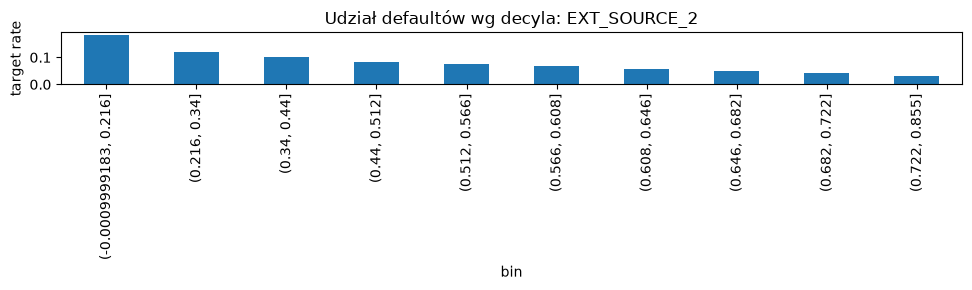

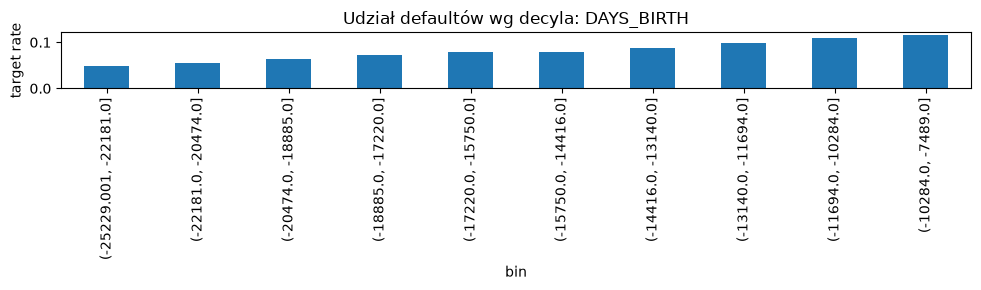

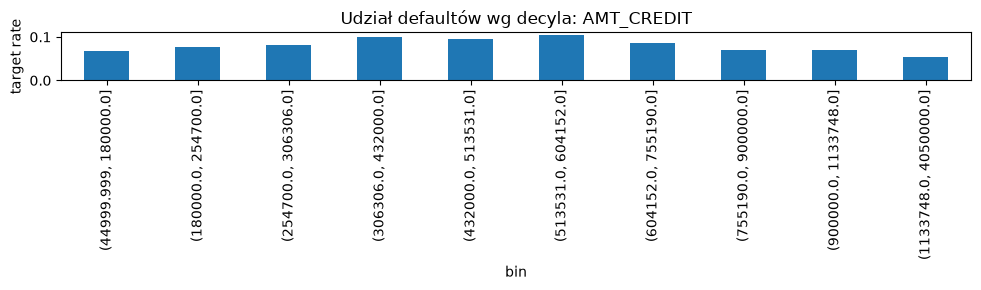

In [11]:
for column in ["EXT_SOURCE_2", "DAYS_BIRTH", "AMT_CREDIT"]:
    table = target_rate_by_bin(df, column, bins=10)
    ax = table.plot.bar(x="bin", y="target_rate", legend=False, figsize=(10, 3))
    ax.set_title(f"Udział defaultów wg decyla: {column}")
    ax.set_ylabel("target rate")
    plt.tight_layout()
    plt.show()

## 7. Wartości odstające

Decyzja: **zostawiamy**. `_safe_divide` w `features/ratios.py` i tak
chroni przed zerem w mianowniku, a `StandardScaler` na regresji
logistycznej z regularyzacją L2 radzi sobie z ogonami. Przycinanie
byłoby kolejną decyzją do obrony bez dowodu, że coś daje.

In [12]:
df[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "CNT_CHILDREN"]].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99, 0.999]
)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CNT_CHILDREN
count,3.075110e+05,3.075110e+05,307499.000000,307511.000000
mean,1.687979e+05,5.990260e+05,27108.573909,0.417052
std,2.371231e+05,4.024908e+05,14493.737315,0.722121
min,2.565000e+04,4.500000e+04,1615.500000,0.000000
1%,4.500000e+04,7.641000e+04,6182.910000,0.000000
25%,1.125000e+05,2.700000e+05,16524.000000,0.000000
50%,1.471500e+05,5.135310e+05,24903.000000,0.000000
75%,2.025000e+05,8.086500e+05,34596.000000,1.000000
99%,4.725000e+05,1.854000e+06,70006.500000,3.000000
99.9%,9.000000e+05,2.517300e+06,110047.500000,4.000000


## 8. Przegląd pod kątem przecieku

Pytanie do każdej zostawionej kolumny: *czy to jest znane w momencie
składania wniosku?*

| Grupa kolumn | Znane przy wniosku? | Werdykt |
|---|---|---|
| `AMT_*`, `NAME_*`, `CODE_GENDER`, `CNT_*` | tak — dane z formularza | zostaje |
| `DAYS_*` | tak — liczone względem daty wniosku | zostaje |
| `EXT_SOURCE_*` | tak — scoring zewnętrzny pobierany przy wniosku | zostaje |
| `AMT_REQ_CREDIT_BUREAU_*` | tak — zapytania **przed** decyzją, nie po | zostaje |
| `REGION_*`, blok mieszkaniowy | tak — dane adresowe | zostaje |
| `FLAG_DOCUMENT_*` | tak — komplet dokumentów przy składaniu | zostaje |
| `OBS_*` / `DEF_*_CNT_SOCIAL_CIRCLE` | tak — historia kręgu społecznego | zostaje |

**Żadna kolumna nie koduje informacji z przyszłości.** `TARGET`
i `SK_ID_CURR` nie są cechami i są usuwane w `train.split`.

## 9. Podsumowanie decyzji

Poniższe krotki są przepisywane do `src/config.py` (Zadanie 3 planu).

In [13]:
BLOCK_CONCEPTS = [
    "APARTMENTS", "BASEMENTAREA", "COMMONAREA", "ELEVATORS", "ENTRANCES",
    "FLOORSMAX", "FLOORSMIN", "LANDAREA", "LIVINGAPARTMENTS", "LIVINGAREA",
    "NONLIVINGAPARTMENTS", "NONLIVINGAREA", "YEARS_BEGINEXPLUATATION",
    "YEARS_BUILD",
]
block_dupes = [f"{c}_{s}" for c in BLOCK_CONCEPTS for s in ("AVG", "MODE")]
weak_docs = doc_table.loc[doc_table["top_share"] >= 0.99, "column"].tolist()

dropped = sorted(
    block_dupes
    + weak_docs
    + ["FLAG_EMP_PHONE", "OBS_60_CNT_SOCIAL_CIRCLE", "REGION_RATING_CLIENT"]
)
assert set(dropped) <= set(df.columns), set(dropped) - set(df.columns)
print(f"DROPPED_COLUMNS: {len(dropped)} kolumn")
for name in dropped:
    print(f"    \"{name}\",")

DROPPED_COLUMNS: 47 kolumn
    "APARTMENTS_AVG",
    "APARTMENTS_MODE",
    "BASEMENTAREA_AVG",
    "BASEMENTAREA_MODE",
    "COMMONAREA_AVG",
    "COMMONAREA_MODE",
    "ELEVATORS_AVG",
    "ELEVATORS_MODE",
    "ENTRANCES_AVG",
    "ENTRANCES_MODE",
    "FLAG_DOCUMENT_10",
    "FLAG_DOCUMENT_11",
    "FLAG_DOCUMENT_12",
    "FLAG_DOCUMENT_13",
    "FLAG_DOCUMENT_14",
    "FLAG_DOCUMENT_15",
    "FLAG_DOCUMENT_16",
    "FLAG_DOCUMENT_17",
    "FLAG_DOCUMENT_18",
    "FLAG_DOCUMENT_19",
    "FLAG_DOCUMENT_2",
    "FLAG_DOCUMENT_20",
    "FLAG_DOCUMENT_21",
    "FLAG_DOCUMENT_4",
    "FLAG_DOCUMENT_7",
    "FLAG_DOCUMENT_9",
    "FLAG_EMP_PHONE",
    "FLOORSMAX_AVG",
    "FLOORSMAX_MODE",
    "FLOORSMIN_AVG",
    "FLOORSMIN_MODE",
    "LANDAREA_AVG",
    "LANDAREA_MODE",
    "LIVINGAPARTMENTS_AVG",
    "LIVINGAPARTMENTS_MODE",
    "LIVINGAREA_AVG",
    "LIVINGAREA_MODE",
    "NONLIVINGAPARTMENTS_AVG",
    "NONLIVINGAPARTMENTS_MODE",
    "NONLIVINGAREA_AVG",
    "NONLIVINGAREA_MODE",
   

In [14]:
informative = [
    "AMT_REQ_CREDIT_BUREAU_YEAR",  # brak = klient bez historii w biurze
    "EXT_SOURCE_1",                # 56% braków, najsilniejsza rodzina cech
    "EXT_SOURCE_3",                # 20% braków
    "OWN_CAR_AGE",                 # not_applicable: brak auta (zweryfikowane)
    "TOTALAREA_MODE",              # reprezentant bloku mieszkaniowego
]
print(f"INFORMATIVE_MISSING: {len(informative)} kolumn")
print(f"Kolumn cech po usunięciu: {df.shape[1] - 2 - len(dropped)}")

INFORMATIVE_MISSING: 5 kolumn
Kolumn cech po usunięciu: 73
